In [9]:
!pip install -q torch torchvision matplotlib pillow numpy

In [ ]:
import os
os.makedirs("outputs", exist_ok=True)
print("Folders created")

Folders created


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from torchvision import datasets, transforms
import torch

print("Loading Oxford-102 Flowers dataset")

transform = transforms.Compose([
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
])

train_set = datasets.Flowers102(root="./data/flowers", split="train", download=True, transform=transform)
val_set   = datasets.Flowers102(root="./data/flowers", split="val",   download=True, transform=transform)
test_set  = datasets.Flowers102(root="./data/flowers", split="test",  download=True, transform=transform)

print("\n" + "="*60)
print("OXFORD-102 FLOWERS – DATASET STATISTICS")
print("="*60)
print(f"Train images      : {len(train_set)}")
print(f"Validation images : {len(val_set)}")
print(f"Test images       : {len(test_set)}")
print(f"Total images      : {len(train_set) + len(val_set) + len(test_set)}")
print(f"Number of classes : 102")

labels = [y for _, y in train_set]
counts = Counter(labels)
vals = list(counts.values())
print(f"\nSamples per class (train):")
print(f"  Min    : {min(vals)}")
print(f"  Max    : {max(vals)}")
print(f"  Mean   : {np.mean(vals):.1f}")
print(f"  Median : {np.median(vals):.1f}")

img, label = train_set[0]
print(f"\nImage tensor shape after transform: {tuple(img.shape)}  (C, H, W)")
print("All images are resized + center-cropped to 128×128.")

Loading Oxford-102 Flowers dataset


100%|██████████| 345M/345M [00:01<00:00, 195MB/s]
100%|██████████| 502/502 [00:00<00:00, 901kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 13.8MB/s]



OXFORD-102 FLOWERS – DATASET STATISTICS
Train images      : 1020
Validation images : 1020
Test images       : 6149
Total images      : 8189
Number of classes : 102

Samples per class (train):
  Min    : 10
  Max    : 10
  Mean   : 10.0
  Median : 10.0

Image tensor shape after transform: (3, 128, 128)  (C, H, W)
All images are resized + center-cropped to 128×128.


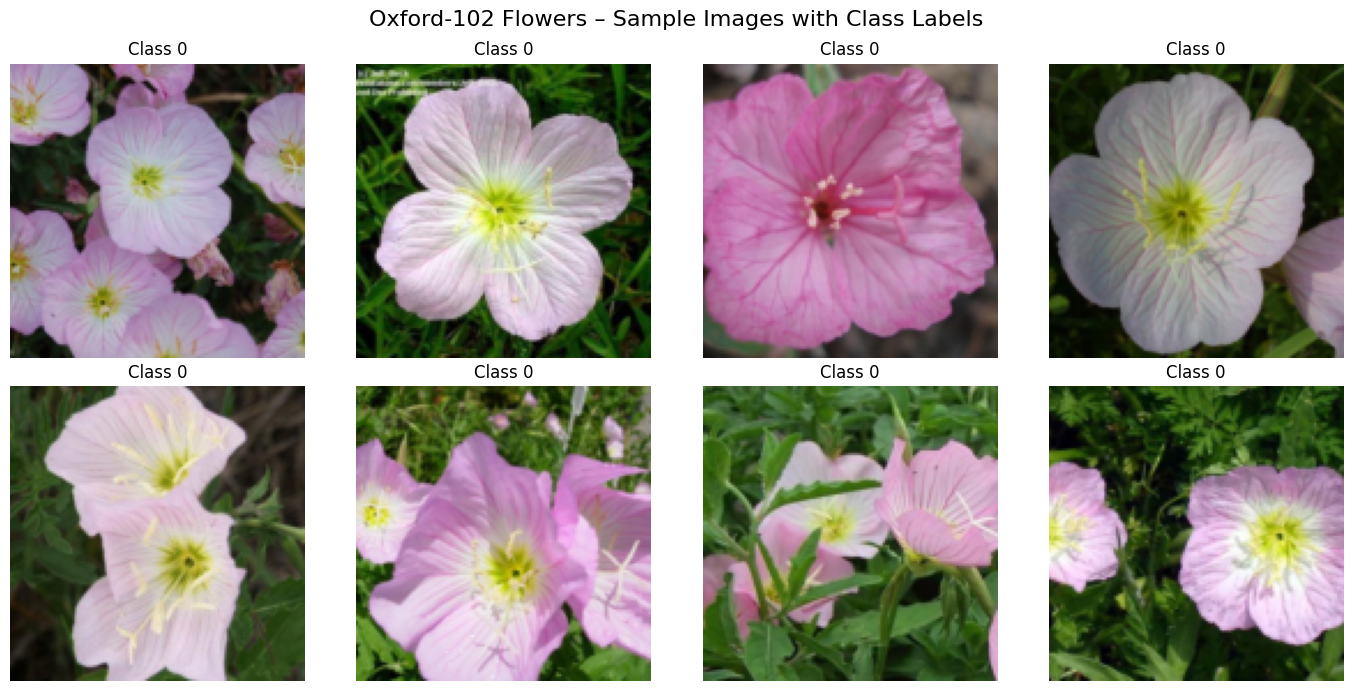

Saved → outputs/day1_dataset_samples_0.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img, label = train_set[i]
    img_np = img.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(f"Class {label}", fontsize=12)
    ax.axis("off")

plt.suptitle("Oxford-102 Flowers – Sample Images with Class Labels", fontsize=16)
plt.tight_layout()
plt.savefig("outputs/day1_dataset_samples.png", dpi=120, bbox_inches="tight")
plt.show()

print("Saved → outputs/day1_dataset_samples_0.png")

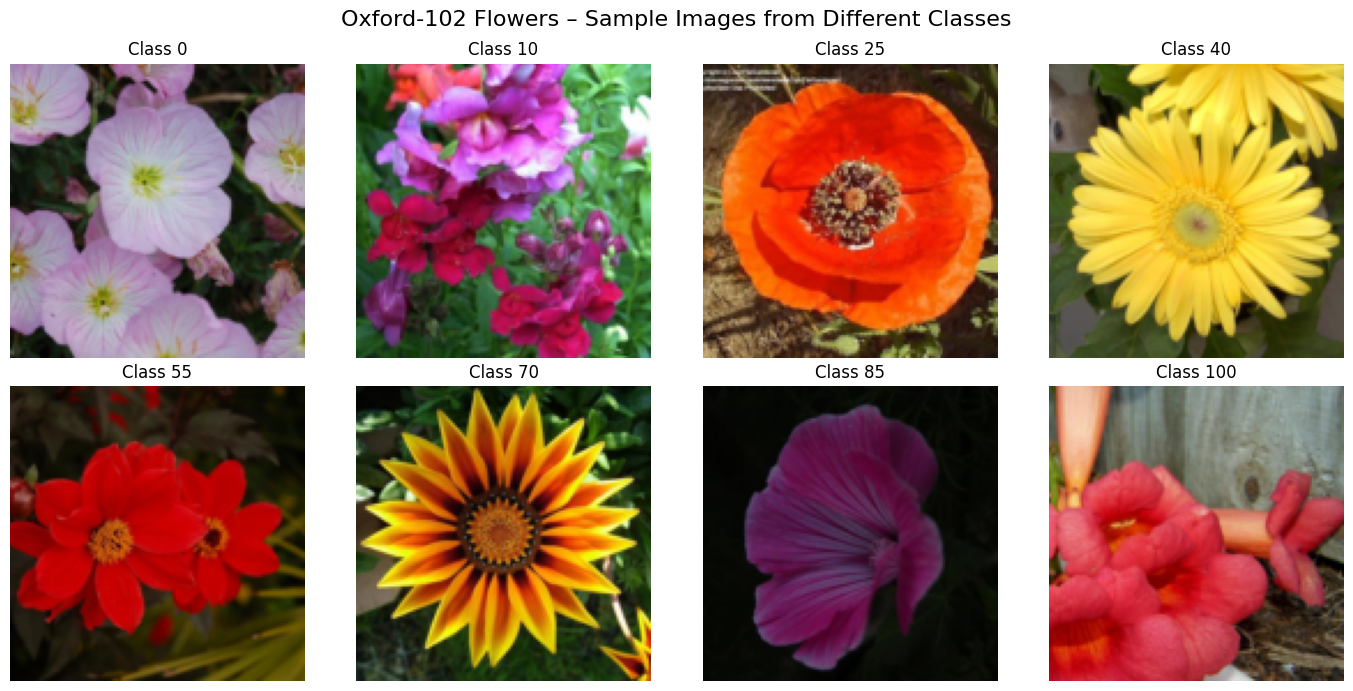

Saved → outputs/day1_dataset_samples.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

# Show one image from different classes
class_indices = [0, 10, 25, 40, 55, 70, 85, 100]

for i, ax in enumerate(axes):
    # Find the first image that belongs to this class
    for idx in range(len(train_set)):
        img, label = train_set[idx]
        if label == class_indices[i]:
            break

    img_np = img.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(f"Class {label}", fontsize=12)
    ax.axis("off")

plt.suptitle("Oxford-102 Flowers – Sample Images from Different Classes", fontsize=16)
plt.tight_layout()
plt.savefig("outputs/day1_dataset_samples.png", dpi=120, bbox_inches="tight")
plt.show()

print("Saved → outputs/day1_dataset_samples.png")